# Relacion 5 Nanoelectrónica

### Ejercicio 1: Realizar ejercicio 5.1 de Marc Baldo.

### Ejercicio 2:

**Considere el hilo (Quantum Wire) de la siguiente figura: Este hilo presenta solo dos modos energéticos localizados en $E_{c1}=-4.7$ eV y en $E_{c2}=-4.6$ eV. Desarrolle una expresión analítica de la curva $I_{DS}-V_{DS}$ en función de $V_{GS} a T=0K. Represente la solución para 0<$V_{DS}$<0.5 en los casos $V_{GS}$ = 0.3V, 0.35V, 0.4V, 0.45V, 0.5V. Suponer $C_S=C_D= 0$, $C_G = 50$aF/nm y L=100nm**

In [3]:
### LIBRERIAS ########################

import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import quad

In [2]:
### Constantes universales #######################

hbar = 6.582*10**(-16)     #eV*s

h = 4.1357*10**(-15)        #eV*s

q = 1.602*10**(-19)         #C

kbtz = 8.617*10**(-5)       #eV/K cte de boltzmann 

m = 9.1*10**(-31)           #kg

In [4]:
### Definición de parámetros para los ejercicios ############################

T = 0               #K
KT = 0.026*T/300    #eV
L = 100             #nm
Ef0 = -5.0          #eV

mu_s0 = Ef0     
mu_d0 = Ef0

G0 = 2 * q / h   # A/V

Cs = 0
Cd = 0
Cg = 50             #aF/nm


Vmax = 10.0         #V
numpasos = 801      #Cantidad de pasos desde -Vmax hasta Vmax
precision = 10**(-6)    #Precisión a la hora de converger U
alfa = 0.1              #Constante para la convergencia (Para valores mayores a 0.15 daba resultados raros)


#Creo el vector de voltajes y las energías

VGS_list = [0.3, 0.35, 0.4, 0.45, 0.5]
Ec_modes_0 = np.array([-4.7, -4.6])   # eV
numpasosE=4000  #Si pones menos de 3000 las curvas salen woobly, salen no rectas.



#### PARA T = 0k

In [5]:
import numpy as np
import matplotlib.pyplot as plt

T = 1e-6    # K

def fermi(energia, e_fermi):
    """
    Args:
        energia (Float or array): Pásale la energía actual del nivel
        e_fermi (Float): Nivel de energía de fermi
    """
    x = (energia - e_fermi)/(KT + 1e-15)
    x_clipped = np.clip(x, -100.0, 100.0)
    return 1.0/(1.0 + np.exp(x_clipped))        #Si no acoto por arriba y por abajo el programa tarda demasiado.


def num_open_modes(E, VGS):
    Ec_eff = Ec_modes_0 - VGS
    return np.sum(E >= Ec_eff)  #Esto es un array de true y false. Mira a ver si cumple el canal con energía E[i] si al quitarle VGS permite circular electrones, o todavía se queda por arriba.


def current_total(VGS, VDS, EF=Ef0):     #Uso la formula final de las diapositivas para calcular la intensidad. Ojo pero no la discreta, integro usando el trapecio.
    muS = Ef0
    muD = Ef0 - VDS
    Ec_eff = Ec_modes_0 - VGS

    Emin = min(np.min(Ec_eff), muD, muS) - 0.2      #Pongo 0.2 porque el profe puso 0.2 para ver que todo se cumplía. Y efectivamente y de sobra.
    Emax = max(np.max(Ec_eff), muD, muS) + 0.2
    E = np.linspace(Emin, Emax, numpasosE)

    M = np.array([num_open_modes(e, VGS) for e in E], dtype=float)  #Vemos la cantidad de modos para cada energía. Barremos todas las energías y comprobamos. Esto sirve para ver los codos.
    fS = fermi(E, muS)
    fD = fermi(E, muD)

    return G0 * np.trapz(M * (fS - fD), E)  #Integro con trapecio porque sino con quad no funcionaba y con simpson tardaba muchísimo.


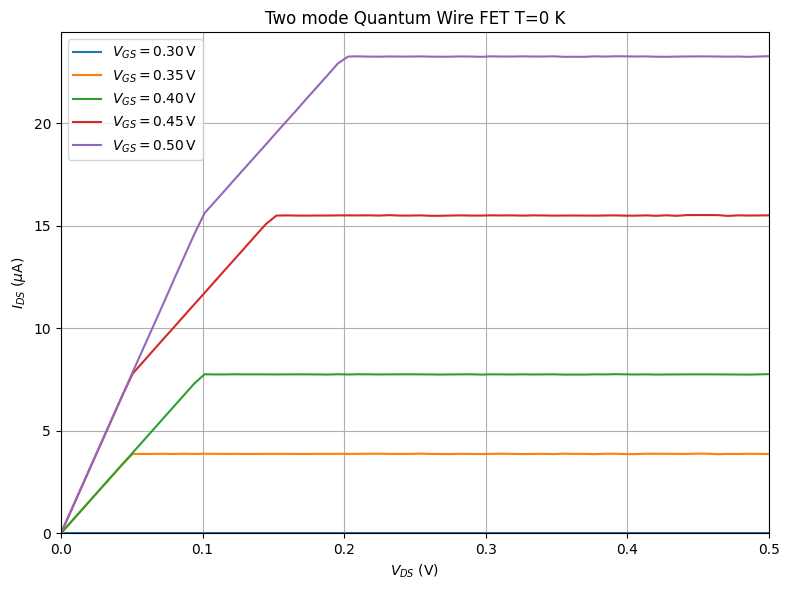

In [6]:
### CODIGO PARA PLOTEAR ###########################
VGS_values = [0.30, 0.35, 0.40, 0.45, 0.50]
VDS_array = np.linspace(0, 0.5, 70)

plt.figure(figsize=(8, 6))

for VGS in VGS_values:
    IDS = np.array([current_total(VGS, VDS) for VDS in VDS_array])
    plt.plot(VDS_array, IDS * 1e6, label=fr"$V_{{GS}}={VGS:.2f}\,\mathrm{{V}}$")

plt.xlabel(r"$V_{DS}$ (V)")
plt.ylabel(r"$I_{DS}$ ($\mu$A)")
plt.title(r"Two mode Quantum Wire FET T=0 K")
plt.grid()
plt.legend()
plt.xlim(0, 0.5)
plt.ylim(bottom=0)
plt.tight_layout()
plt.show()

#### Para T=298K

In [7]:
###PARA 298K ########################

T = 298      # K
KT = 0.026*T/300    #eV 

def fermi(energia, e_fermi):
    """
    Args:
        energia (Float or array): Pásale la energía actual del nivel
        e_fermi (Float): Nivel de energía de fermi
    """
    x = (energia - e_fermi)/(KT + 1e-15)
    x_clipped = np.clip(x, -100.0, 100.0)
    return 1.0/(1.0 + np.exp(x_clipped))        #Si no acoto por arriba y por abajo el programa tarda demasiado.


def num_open_modes(E, VGS):
    Ec_eff = Ec_modes_0 - VGS
    return np.sum(E >= Ec_eff)  #Esto es un array de true y false. Mira a ver si cumple el canal con energía E[i] si al quitarle VGS permite circular electrones, o todavía se queda por arriba.


def current_total(VGS, VDS, EF=Ef0):     #Uso la formula final de las diapositivas para calcular la intensidad. Ojo pero no la discreta, integro usando el trapecio.
    muS = Ef0
    muD = Ef0 - VDS
    Ec_eff = Ec_modes_0 - VGS

    Emin = min(np.min(Ec_eff), muD, muS) - 0.2      #Pongo 0.2 porque el profe puso 0.2 para ver que todo se cumplía. Y efectivamente y de sobra.
    Emax = max(np.max(Ec_eff), muD, muS) + 0.2
    E = np.linspace(Emin, Emax, numpasosE)

    M = np.array([num_open_modes(e, VGS) for e in E], dtype=float)  #Vemos la cantidad de modos para cada energía. Barremos todas las energías y comprobamos. Esto sirve para ver los codos.
    fS = fermi(E, muS)
    fD = fermi(E, muD)

    return G0 * np.trapz(M * (fS - fD), E)  #Integro con trapecio porque sino con quad no funcionaba y con simpson tardaba muchísimo.


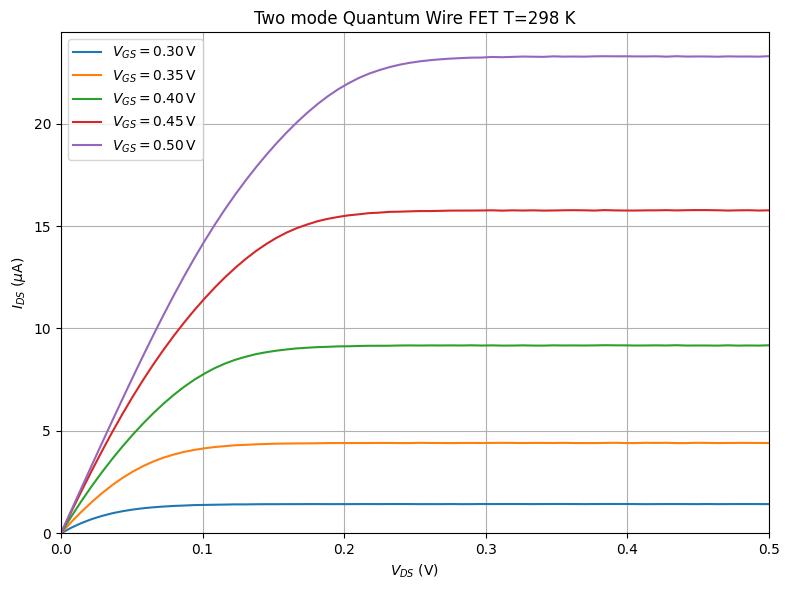

In [8]:
### CODIGO PARA PLOTEAR ###########################
VGS_values = [0.30, 0.35, 0.40, 0.45, 0.50]
VDS_array = np.linspace(0, 0.5, 70)

plt.figure(figsize=(8, 6))

for VGS in VGS_values:
    IDS = np.array([current_total(VGS, VDS) for VDS in VDS_array])
    plt.plot(VDS_array, IDS * 1e6, label=fr"$V_{{GS}}={VGS:.2f}\,\mathrm{{V}}$")

plt.xlabel(r"$V_{DS}$ (V)")
plt.ylabel(r"$I_{DS}$ ($\mu$A)")
plt.title(r"Two mode Quantum Wire FET T=298 K")
plt.grid()
plt.legend()
plt.xlim(0, 0.5)
plt.ylim(bottom=0)
plt.tight_layout()
plt.show()

Ahora veamos si le metemos elefecto de charging. Es decir, que U ya no sea -qVgs.

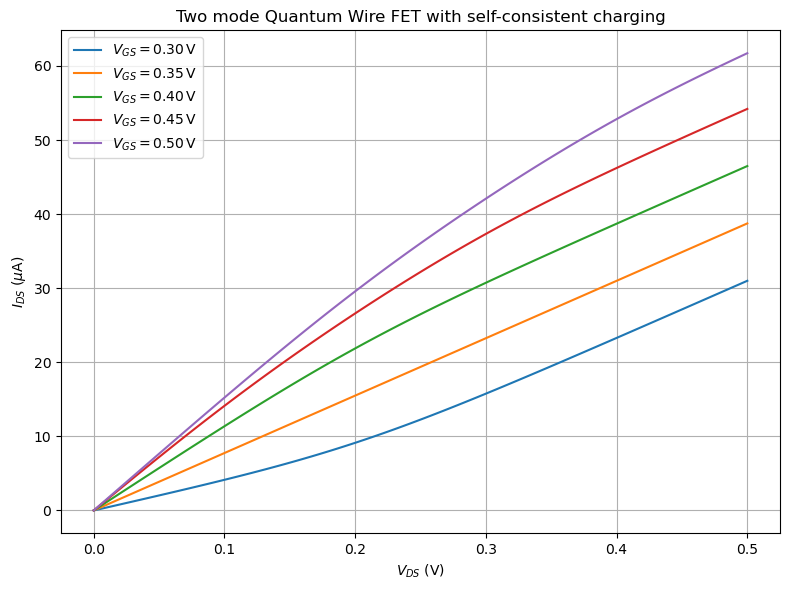

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ==============================
# Parámetros
# ==============================
T = 298
kB_eV = 8.617333262e-5
KT = kB_eV * T

q = 1.602176634e-19          # C
h = 4.135667696e-15          # eV*s

Ef0 = -5.0                   # eV
Ec_list = np.array([-4.7, -4.6])   # eV

VGS_values = [0.30, 0.35, 0.40, 0.45, 0.50]
VDS_array = np.linspace(0, 0.5, 100)

Emin = -5.8
Emax = -3.8
nE = 4000
E = np.linspace(Emin, Emax, nE)

# Capacitancias
Cs = 0.0
Cd = 0.0
Cg = 50e-18 * 100   # 50 aF/nm * 100 nm = 5e-15 F
CES = Cs + Cd + Cg

# Charging
N0 = 0.0            # referencia
mix = 0.1           # mixing numérico
tol = 1e-8
max_iter = 100

# fuerza del charging en eV por electrón:
# q^2/C tiene unidades J, así que dividimos por q para pasarlo a eV
U0 = q / CES        # eV por electrón

# ==============================
# Funciones
# ==============================
def fermi(E, mu):
    if T == 0:
        return np.where(E <= mu, 1.0, 0.0)
    x = (E - mu) / (KT + 1e-15)
    x = np.clip(x, -100, 100)
    return 1.0 / (1.0 + np.exp(x))

def num_open_modes(E_point, U):
    Ec_eff = Ec_list + U
    return np.sum(E_point >= Ec_eff)

def current_for_U(VDS, U):
    mu_s = Ef0 + VDS/2
    mu_d = Ef0 - VDS/2

    M = np.array([num_open_modes(e, U) for e in E], dtype=float)
    fS = fermi(E, mu_s)
    fD = fermi(E, mu_d)

    I = (2*q/h) * np.trapezoid(M * (fS - fD), E)
    return I

def charge_for_U(VDS, U):
    """
    Ocupación del top-of-the-barrier.
    Modelo simple:
    N(E) = M(E) * (fS + fD)/2
    """
    mu_s = Ef0 + VDS/2
    mu_d = Ef0 - VDS/2

    M = np.array([num_open_modes(e, U) for e in E], dtype=float)
    fS = fermi(E, mu_s)
    fD = fermi(E, mu_d)

    N = np.trapezoid(M * 0.5 * (fS + fD), E)
    return N

def solve_self_consistent_U(VGS, VDS):
    # parte electrostática
    UL = -(Cg/CES)*VGS - (Cd/CES)*VDS

    U = UL   # semilla inicial

    for _ in range(max_iter):
        N = charge_for_U(VDS, U)

        U_new = UL + U0 * (N - N0)

        # mixing para estabilizar
        U_mixed = (1 - mix)*U + mix*U_new

        if abs(U_mixed - U) < tol:
            return U_mixed

        U = U_mixed

    return U

def current_total_selfconsistent(VGS, VDS):
    U_sc = solve_self_consistent_U(VGS, VDS)
    I_sc = current_for_U(VDS, U_sc)
    return I_sc, U_sc


plt.figure(figsize=(8,6))

for VGS in VGS_values:
    IDS = []

    for VDS in VDS_array:
        I_sc, U_sc = current_total_selfconsistent(VGS, VDS)
        IDS.append(I_sc)

    IDS = np.array(IDS)
    plt.plot(VDS_array, IDS*1e6, label=fr"$V_{{GS}}={VGS:.2f}\,\mathrm{{V}}$")

plt.xlabel(r"$V_{DS}$ (V)")
plt.ylabel(r"$I_{DS}$ ($\mu$A)")
plt.title("Two mode Quantum Wire FET with self-consistent charging")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

### Ejercicio 3 Deducir las siguientes expresiones
$$
I_{DS}
$$

Partimos de la ecuación de la intensidad, que como estamos en 2D, $\tau = L/V_x$ siendo $V_x$ la componente que conecta la fuente y drenador
$$
I = \frac{q (N_S-N_D)}{\tau} = \frac{qv_x(N_S-N_D)}{L}
$$

Por otra parte, para obtener ese N necesitamos la densidad de estados. Dicho diferencial luego integraremos para obtener N. Si escribimos N en función de k y luego derivamos obtenemos
$$
g(k)dk = \frac{2LW d^2k}{(2\pi)^2}
$$
Si ahora lo expresamos en "polares" con k el módulo y $\theta$ el ángulo (siendo la dirección y con ángulo 0 y creciente en sentido horario, o viceversa) y le adjuntamos la velocidad $v_x$:
$$
g(k)\cdot v_xdkd\theta = \frac{2LWk }{(2\pi)^2}\cdot \frac{\hbar k_x}{m}dk d\theta = \frac{2LWk }{(2\pi)^2}\cdot \frac{\hbar k sin(\theta)}{m}dk d\theta
$$

Ahora usamos la relación de dispersión semiclásica: 
$$E - E_c - U = 1/2 m v^2 = \frac{\hbar^2 k^2}{2m}$$
$$ k = \sqrt{\frac{2m}{\hbar^2}(E-E_c-U)}$$

Sustituyendo tanto k como dk en la ecuación de $g(k)*v_x$ obtenemos:

$$
gv_xdEd\theta = \frac{LW}{2\pi^2\hbar^2}\sqrt{2m(E-E_c-U)}sin(\theta)\cdot u(E-E_c-U)dEd\theta
$$

La función escalón 'u' sale del artilugio de que la raíz no puede ser negativa.
Retomamos ahora la ecuación de la intensidad del principio y sustituimos esta densidad de estado por velocidad

$$
I= \frac{qW}{2\pi^2\hbar^2}\int_0^\pi \int_{-\infty}^{\infty} \sqrt{2m(E-E_c-U)}u(E-E_c-U)(f(E,\mu_S)-f(E,\mu_D))sin(\theta)dEd\theta
$$
La integral en $\theta$ da 2, así que nos quitamos el 2 del denominador y pasamos solo a integrar en E.

Ahora tenemos que distinguir varios casos: cuando no conduce, cuando conduce linealmente y cuando satura. Podríamos considerar solo 2, cuando conduce y cuando no.

Cuando no conduce tenemos que $V_{GS}$ < $V_T$ o voltaje umbral. Como no hay estados entonces $g=0$ y $U=-q\eta_0 V_{GS}$ con $\eta_0 = \frac{C_G}{C_{ES}}$ y $C_{ES} = C_D + C_S + C_G$. I=0.

Cuando empieza a conducir tenemos que $V_{GS}$ > $V_T$ (y si no satura, $V_{DS}$ < $(V_{GS}-V_T)$). Justo cuando empieza tenemos que $\mu_S = E_c - U$ por tanto podemos sacar la expresión de $$V_T = \frac{E_c-\mu_S}{q\eta_0}$$

Si seguimos aumentando $V_{GS}$ llegamos a la región lineal y ya no podemos ignorar los efectos de carga, por lo que tenemos que modificar nuestra U con un nuevo $\eta = \frac{C_G}{C_{ES} + C_q}$ y $C_q = \frac{q^2mWL}{2\pi\hbar^2}$ (en 2D):
$$
U = -q\eta_0V_T - q\eta(V_{GS}-V_T)
$$

Con todo esto podemos modificar la expresión anterior de la intensidad poniéndolo en función de estos parámetros en lugar de $E_c$ y U. Sabemos que $E_c + U = \mu_s -\eta q (V_{GS} - V_T)$. También tenemos que modificar los límites de integración, ya no son + y - infinito. Para el límite de +infinito tenemos ahora la altura $\mu_s$, los electrones de la fuente no van a subir porque es un metal y su función de ocupación es un escalón. Para el límite bajo tenemos que tener en cuenta si hemos saturado o no. Si no hemos saturado entonces el drenador es el que manda ya que se encuentran antes al drenador antes que el "fondo" del hilo, por tanto el límite inferior sería $\mu_s - qV_{DS}$. Procedamos con esta interpretación.

$$
I = \frac{qW}{\pi^2\hbar^2}\int_{\mu_s-V_{DS}}^{\mu_s}\sqrt{2m(E-\mu_s+\eta q (V_{GS}-V_T))}dE
$$

Ahora hacemos un cambio de variable $t = E - \mu_S + \eta q (V_{GS}-V_T)$ con límites $t_1 = \eta q (V_{GS} - V_T)$ y $t_2 = \eta q (V_{GS}-V_T-\frac{V_{DS}}{\eta})$ lo que nos da la integral:

$$
I= \frac{\sqrt{2m}qW}{\pi^2\hbar^2}\int_{t_2}^{t_1}t^1/2dt
$$
Tras resolver esta integral directa y sustituir $t_1$ y $t_2$ obtenemos:

$$
I = \frac{qW}{\pi^2\hbar^2}\sqrt{8m/9}(\eta q)^{3/2}\left((V_{GS}-V_T)^{3/2} - (V_{GS}-V_T-V_{DS}/\eta)^{3/2}\right)
$$
que es la expresión primera a demostrar.

Si ahora estamos en región de saturación podemos hacer dos cosas. O bien sustituir en la ecuación anterior que $V_{GS} - V_T = V_{DS}/\eta$ o en los límites de integración inferiores. ¿Por qué? Porque ahora sí se encuentran el fondo del hilo antes que el drenador, por lo que la energía mínima que obtienen no es la del drenador sino la del hilo.


